In [1]:
import pandas as pd
import numpy as np
from google_sheet_api import GoogleSheetAPI
import matplotlib.pyplot as plt
from IPython.display import display, HTML

google_sheet_name = 'MX3-Auto-Bench1'
worksheets = {'rpi5_400_hat': '1042661453', 
              'rpi5_500_hat': '1367399762',
              'rpi5_600_hat': '1560271992',
              'rpi5_400': '663317078', 
              'rpi5_500': '1396793757',
              'opi5_500': '0',
              'opi5_400': '845338970',
              'opi5_600': '798154479',
              'summary': '890096994'}

In [2]:
gs = GoogleSheetAPI('Jetson-NX-16GB')
gs.open_worksheet('382431347')
yolobench_subset = gs.get_dataframe('A1:A37', includes_header=True)


<bound method Spreadsheet.worksheets of <Spreadsheet 'Jetson-NX-16GB' id:18-cCy5W8Z7O-ZjL8d1g7kT0NVT0qIFpmlpEz8BCv0fY>>


# Yolobench run on MX3 with ARM Hosts

I ran the 711 models from Yolobench on the MX3 with two different ARM hosts: Raspberry Pi 5, and Orange Pi 5+. On the Orange Pi 5+, the M.2 module can plug directly into the board, but on the Raspberry Pi 5 an M.2 HAT is required. 

I ran the test with two different HATS:

1. A 3rd party M.2 Hat: https://www.amazon.com/Geekworm-X1001-Key-M-Peripheral-Raspberry/dp/B0CPPGGDQT/ref=asc_df_B0CPPGGDQT/?tag=hyprod-20&linkCode=df0&hvadid=697388180372&hvpos=&hvnetw=g&hvrand=3690076237866677783&hvpone=&hvptwo=&hvqmt=&hvdev=c&hvdvcmdl=&hvlocint=&hvlocphy=9191953&hvtargid=pla-2275489259713&psc=1&mcid=1cc97183ca983b81acde2e7522945324 .  It turns out that this HAT is limited to supplying 5 Watts to the M.2 module, unless an extra 5V power cable is connected (which I don't have). I refer to this one as "HAT".

2. The official one from Raspberry Pi: https://www.raspberrypi.com/products/m2-hat-plus/ . This one uses a GPIO pin to deliver extra power to the M.2 module (up to 10 Watts, assuming there is that enough power available from the power supply).  It only fits up to length 42 mm, so I had to have the 80 mm M.2 module hang off the end and tape it down. I initially didn't use this one because of the length limitation, without realizing the other option is power limited. I refer to this one as "HAT+"

The Orange Pi 5+ uses a 20 W power supply and the Raspberry Pi 5 uses a 27 W power supply, but both may run into limitations of the power supplied to the M.2 module.  Because of power limitations, but when using an ARM host the MX3 frequency defaults to 500 MHz (compared to 600 MHz for an x86 host).

I ran the tests at three different frequencies: 600 MHz (pushing the limits, many failures), 500 MHz (mostly ok, just a few failures), and 400 MHz (only one failure with the HAT).  The following table summarizes the number of failures:

In [3]:
gs = GoogleSheetAPI(google_sheet_name)
gs.open_worksheet(worksheets['summary'])
summary = gs.get_dataframe('A1:C9', includes_header=True)
display(HTML(summary.to_html()))


<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,SBC,MX3 Freq (MHz),Failures
1,Rpi5 with HAT,400,1
2,Rpi5 with HAT,500,38
3,Rpi5 with HAT+,400,0
4,Rpi5 with HAT+,500,2
5,Rpi5 with HAT+,600,71
6,OPi5+,400,0
7,OPi5+,500,5
8,OPi5+,600,67


In [4]:
def get_combined_table(worksheet_id, rsuffix, use_subset=True):
    # load x86 results from Tim
    data_mx3 = pd.read_csv('yolobench_mx3_fps_latency.csv')
    data_mx3 = data_mx3.set_index('Model')

    # load arm results from spreadsheet
    gs = GoogleSheetAPI(google_sheet_name)
    gs.open_worksheet(worksheet_id)
    data_mx3_arm = gs.get_dataframe('A1:F3556', includes_header=True)
    if use_subset:
        data_mx3_arm = data_mx3_arm[data_mx3_arm.Model.isin(yolobench_subset['Model'])]

    data_mx3_arm = data_mx3_arm.astype({'FPS': 'float'})
    data_mx3_arm = data_mx3_arm.astype({'Sys Power(W)': 'float'})
    data_mx3_arm = data_mx3_arm.set_index('Model')

    data_mx3 = data_mx3.join(data_mx3_arm, lsuffix='_x86', rsuffix=rsuffix)
    
    if use_subset:
        data_mx3 = data_mx3.dropna()

    # number of errors
    num_errors = sum(data_mx3_arm.FPS.isna())
    #print(f'Num missing values: {num_errors}')

    return data_mx3


In [5]:
def geo_mean(xs):
    return np.exp(np.log(xs).mean())


def gen_summary_table(df):
    summary = pd.DataFrame({
        'Geo Mean': df.apply(geo_mean),
        'Mean': df.mean(),
        'Median': df.median(),
    })
    return  summary.T
    
def make_plot(df, png_name=None, freq=None, host=None):
    plt.plot(df.FPS_x86, df.FPS_arm, '.')
    plt.ylabel(f'FPS, MX3 with {host} ({freq} MHz)')
    plt.xlabel('FPS, MX3 with x86 Host (600 MHz)')
    fps_max = 3000
    plt.plot([0, fps_max], [0, fps_max], 'k--')
    if freq:
        slope = freq/600
        plt.plot([0, fps_max], [0, slope * fps_max], 'r--')
    plt.xlim([0, fps_max])
    plt.ylim([0, fps_max])

    num_errors = sum(df.FPS_arm.isna())
    plt.text(100, fps_max-200, f'Failures: {num_errors}')
    # max power would be useful if limited to models which appear in all results (excluding failures)
    max_power = df['Sys Power(W)'].max()
    # plt.text(100, fps_max-400, f'Max Pow: {max_power:.1f}')

    selected_columns = ['FPS_x86', 'FPS_arm', 'Sys Power(W)']
    table = gen_summary_table(df[selected_columns])
    display(HTML(table.to_html()))

    plt.title('Yolobench FPS on MX3, x86 vs. ARM host')
    if png_name:
        plt.savefig(png_name)

The following plots compare each run to the reference FPS values of Yolobench set on MX3 with an x86 host (from Tim). Each of the 711 models is represented by a blue dot.  If the ARM results matched the x86 results the points would fall on the black dotted line.  If the only difference was a frequency scaling, we would expect the points to fall on the red dotted line which has a slope of (ARM_freq / 600 MHz), where ARM_freq is either 400, 500, or 600 MHz. However, because of power limitations and bandwidth limitations, sometimes the points do not follow the red line.

The raw data can be found here:  https://docs.google.com/spreadsheets/d/1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,545.1,371.3,10.6
Mean,740.4,530.8,10.8
Median,550.8,368.4,10.4


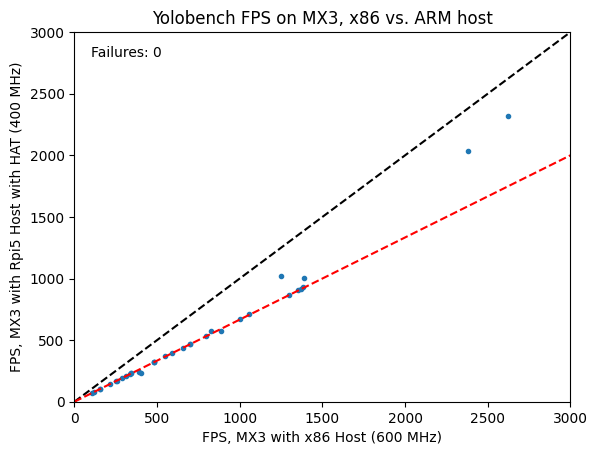

In [6]:
pd.options.display.float_format = '{:.1f}'.format
rpi5 = get_combined_table(worksheets['rpi5_400'], '_arm')
make_plot(rpi5, freq=400, host='Rpi5 Host with HAT')


<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,545.1,218.1,9.8
Mean,740.4,422.6,10.2
Median,550.8,248.1,9.8


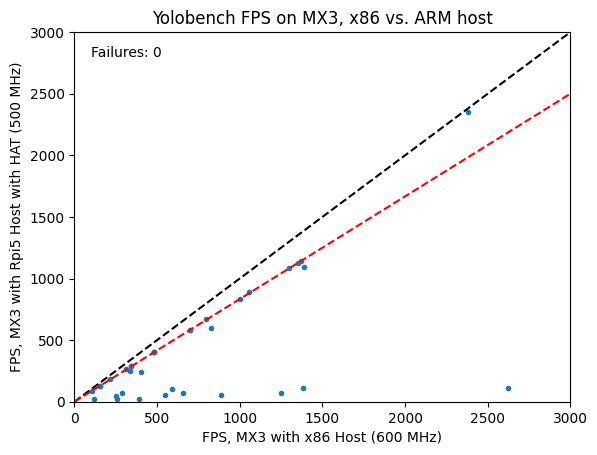

In [7]:
rpi5 = get_combined_table(worksheets['rpi5_500'], '_arm')
make_plot(rpi5, freq=500, host='Rpi5 Host with HAT')

This one has 38 failures, plus many of the models failed in a less obvious way by having a very low FPS.

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,530.0,360.6,9.7
Mean,725.3,519.6,9.9
Median,517.1,346.6,9.2


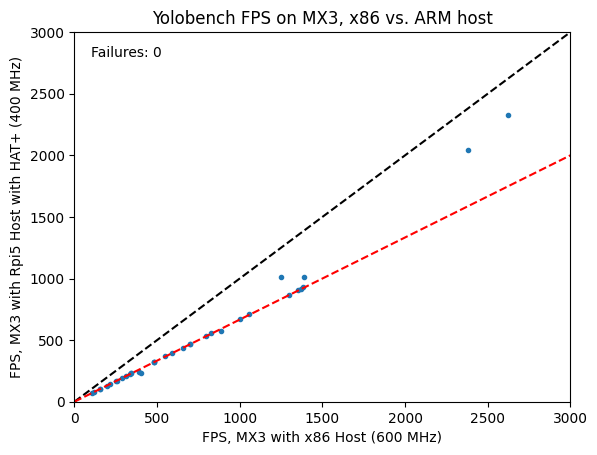

In [8]:
rpi5 = get_combined_table(worksheets['rpi5_400_hat'], '_arm')
make_plot(rpi5, freq=400, host='Rpi5 Host with HAT+')

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,545.1,445.7,10.5
Mean,740.4,625.8,10.7
Median,550.8,460.5,10.2


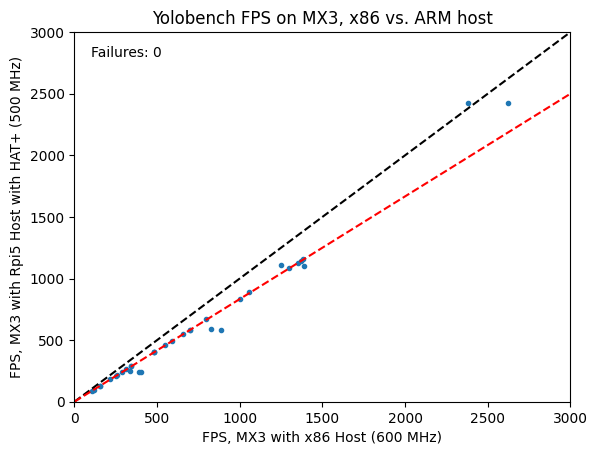

In [22]:
rpi5 = get_combined_table(worksheets['rpi5_500_hat'], '_arm')
make_plot(rpi5, freq=500,  host='Rpi5 Host with HAT+')

In [23]:
set(yolobench_subset.Model) - set(rpi5.index)

{'yolo5m_480'}

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,633.9,588.2,11.8
Mean,812.2,772.4,12.0
Median,655.4,568.7,11.8


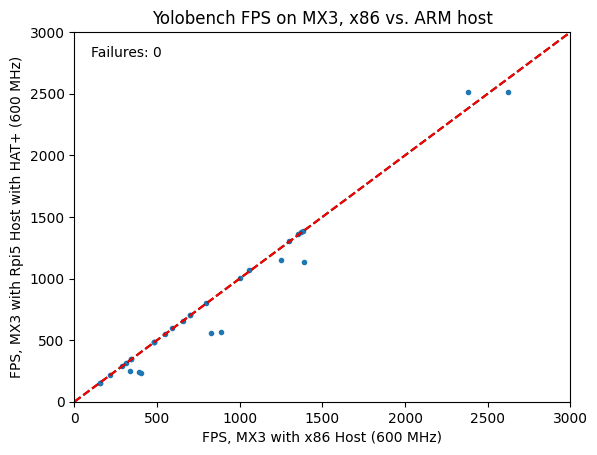

In [11]:
rpi5 = get_combined_table(worksheets['rpi5_600_hat'], '_arm')
make_plot(rpi5, freq=600, host='Rpi5 Host with HAT+')

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,530.0,376.3,11.9
Mean,725.3,544.0,12.2
Median,517.1,358.6,11.9


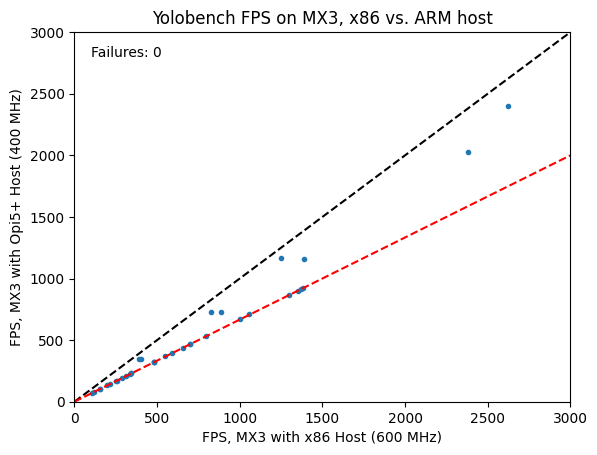

In [12]:
opi5 = get_combined_table(worksheets['opi5_400'], '_arm')
make_plot(opi5, freq=400,  host='Opi5+ Host')

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,545.1,469.6,13.4
Mean,740.4,656.0,13.6
Median,550.8,459.1,13.7


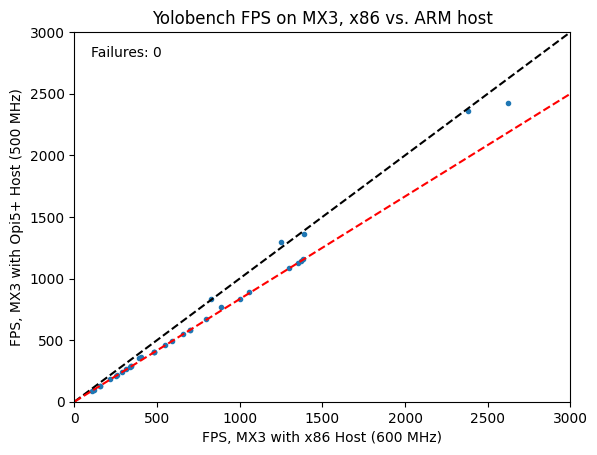

In [24]:
opi5 = get_combined_table(worksheets['opi5_500'], '_arm')
make_plot(opi5, freq=500,  host='Opi5+ Host')

In [25]:
set(yolobench_subset.Model) - set(opi5.index)

{'yolo5m_480'}

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,628.4,620.1,13.4
Mean,809.6,795.6,13.7
Median,655.4,657.3,13.4


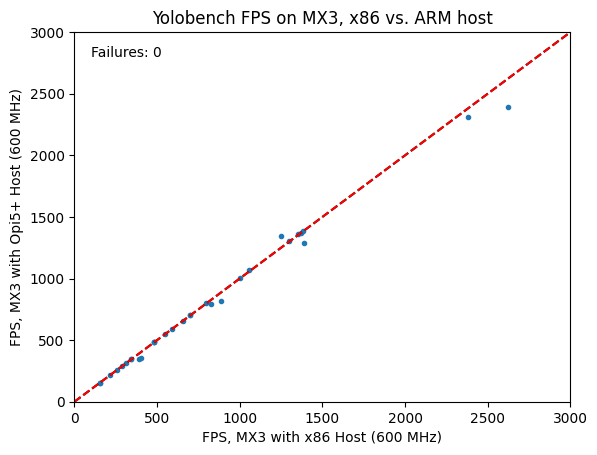

In [14]:
opi5 = get_combined_table(worksheets['opi5_600'], '_arm')
make_plot(opi5, freq=600,  host='Opi5+ Host')

Repeating the RPi5 with HAT+ at 600 MHz here for comparison with the Orange Pi 5+ at 600 MHz. They had a similar number of failures, but for the models which did succeed the Orange Pi 5+ tended to have higher FPS.  This is presumably because the Orange Pi 5+ has more PCIe lanes.

<bound method Spreadsheet.worksheets of <Spreadsheet 'MX3-Auto-Bench1' id:1OZw3g6aHp1pmHMJU2D_8A_2o8z3KGTr8KTaSBHbjD7c>>


,FPS_x86,FPS_arm,Sys Power(W)
Geo Mean,633.9,588.2,11.8
Mean,812.2,772.4,12.0
Median,655.4,568.7,11.8


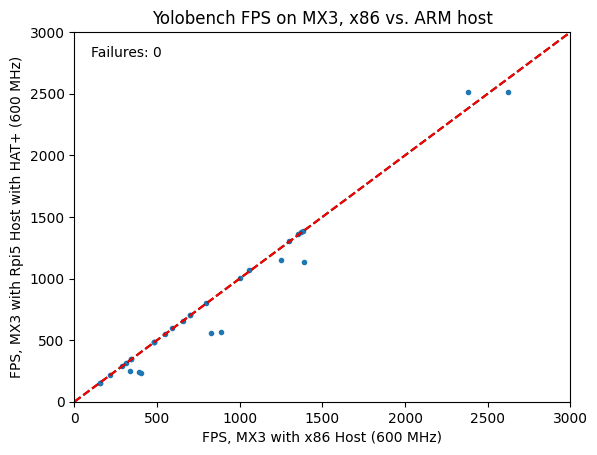

In [15]:
opi5 = get_combined_table(worksheets['rpi5_600_hat'], '_arm')
make_plot(opi5, freq=600,  host='Rpi5 Host with HAT+')